# AI Product Discovery with RAG (Notebook Structure)

This notebook is the **orchestrator** for your repo-based implementation:

- `src/` holds core pipeline logic (cleaning, embeddings, FAISS, ranking, RAG, UI)
- `notebooks/` demonstrates the end-to-end workflow with plots + examples
- `data/` and `artifacts/` are **gitignored**

> **Colab tip**: If running in Colab, clone your repo and run from the repo root.


In [1]:
# Determine if running in Colab (robust, no import errors)
import sys, os

def in_colab() -> bool:
    # Safest: try importing google.colab (catch if package doesn't exist)
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        pass
    # Secondary: module already loaded
    if 'google.colab' in sys.modules:
        return True
    # Optional: environment hints
    return any(k in os.environ for k in ['COLAB_RELEASE_TAG','COLAB_GPU','COLAB_TPU_ADDR'])

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    # change the cwd to the notebooks
    os.chdir("/content/drive/MyDrive/pyramyd_ml")

    # Optional: !pip -q install -r requirements.txt
else:
    print('Running outside Colab')


Mounted at /content/drive


In [2]:
%%bash
export IN_COLAB=0
if python3 -c "import sys; import google.colab" &> /dev/null; then
  IN_COLAB=1
fi

if [ $IN_COLAB -eq 1 ]; then
    set -e
    # Mount Drive first (if not already)
    # python code runs before bash usually, so keep mount in Python cell above
    # Link persistent SSH config into runtime
    mkdir -p ~/.ssh
    ln -sf /content/drive/MyDrive/.ssh/id_ed25519 ~/.ssh/id_ed25519
    ln -sf /content/drive/MyDrive/.ssh/id_ed25519.pub ~/.ssh/id_ed25519.pub
    ln -sf /content/drive/MyDrive/.ssh/known_hosts ~/.ssh/known_hosts

    chmod 700 ~/.ssh
    chmod 600 ~/.ssh/id_ed25519
    chmod 644 ~/.ssh/id_ed25519.pub

    echo "SSH ready."

    git config --global user.name "Zhan"
    git config --global user.email "shizhe_zhang@berkeley.edu"
    ssh -T git@github.com || true
fi


SSH ready.


Hi minikouda/pyramyd_ml! You've successfully authenticated, but GitHub does not provide shell access.


In [3]:
# Ensure repo root is on sys.path so `import src.*` works
# !pwd
# !ls
from pathlib import Path

cwd = Path.cwd()

# If running from repo root, keep it; if from notebooks/, go up one level
if (cwd / 'src').exists():
    repo_root = cwd
elif (cwd.name == 'notebooks') and ((cwd.parent / 'src').exists()):
    repo_root = cwd.parent
else:
    # Fallback: search upwards for a folder containing `src` and `requirements.txt`
    candidates = [cwd, *cwd.parents]
    repo_root = next((p for p in candidates if (p / 'src').exists()), cwd)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print('Repo root:', repo_root)
print('CWD:', cwd)
print('sys.path[0]:', sys.path[0])

Repo root: /content/drive/MyDrive/pyramyd_ml
CWD: /content/drive/MyDrive/pyramyd_ml
sys.path[0]: /content/drive/MyDrive/pyramyd_ml


## 1) Setup & Imports


In [4]:
# (Colab) If you cloned your repo, run this cell from the repo root.
# Example:
# !git clone git@github.com:<YOU>/<REPO>.git
# %cd <REPO>


# Install dependencies (Colab-only). Locally, use: pip install -r requirements.txt
# !pip -q install -r requirements.txt

import os, re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repo modules
from src.config import EMBED_MODEL, LLM_MODEL, ARTIFACT_DIR
from src.data import load_data

# Uncomment as you implement these modules
# from src.embeddings import embed_texts
# from src.index import build_index
# from src.ranker import hybrid_score
# from src.rag import build_prompt

os.makedirs(ARTIFACT_DIR, exist_ok=True)
print("EMBED_MODEL:", EMBED_MODEL)
print("LLM_MODEL:", LLM_MODEL)
print("ARTIFACT_DIR:", ARTIFACT_DIR)


EMBED_MODEL: sentence-transformers/all-MiniLM-L6-v2
LLM_MODEL: Qwen/Qwen2.5-7B-Instruct
ARTIFACT_DIR: artifacts


## 2) Load CSV + Inspect


In [27]:
# Path options:
# - In Colab: upload to /content, or mount Google Drive
# - Locally: point to your local file

CSV_PATH = "data/company_reviews.csv"  # TODO: change to your file path

df_raw = load_data(CSV_PATH)
print("Shape:", df_raw.shape)
display(df_raw.head(3))

# Quick schema + missingness
col_info = pd.DataFrame({
    "col": df_raw.columns,
    "dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
    "missing_%": [df_raw[c].isna().mean()*100 for c in df_raw.columns],
}).sort_values("missing_%", ascending=False)

display(col_info)


Shape: (17050, 20)


,name,rating,reviews,description,happiness,ceo_approval,ceo_count,ratings,locations,roles,salary,interview_experience,interview_difficulty,interview_duration,interview_count,headquarters,employees,industry,revenue,website
0,Sitel,NaN,NaN,"Sitel Group’s 75,000 people across the globe c...","{'Work Happiness Score': '55', 'Achievement': ...",70%,"CEO Approval is based on 4,612 ratings","{'Work/Life Balance': '3.4', 'Compensation/Ben...","{'Paradise, NV': '5.0', 'Pioneer, OH': '4.7', ...","{'Tier 1 Agent': '5.0', 'Director of Operation...",{'Customer Service Representative': '$14.48 pe...,Favorable,Easy,About a day or two,Based on 645 interviews,"600 Brickell Ave Miami, FL 33131 Vereinigte St...","10,000+",Telecommunications,$1B to $5B (USD),Twitter\nFacebook\nSitel website
1,Meadowbrook Rehabilitation,3.7,21 reviews,You'll work with the most experienced and loya...,{},NaN,NaN,"{'Work/Life Balance': '4.1', 'Compensation/Ben...",{},{},{},Favorable,Easy,NaN,Based on 5 interviews,Illinois,NaN,Healthcare,NaN,Meadowbrook Rehabilitation website
2,Intermountain,4.0,23 reviews,Why Intermountain?\n\nWe Bring Hope\n\nWith ou...,{},88%,CEO Approval is based on 17 ratings,"{'Work/Life Balance': '3.5', 'Compensation/Ben...",{},{},{'Mental Health Technician': '$13.16 per hour'...,Favorable,Medium,About a day or two,Based on 8 interviews,"Headquarters: 3240 Dredge Dr. Helena, MT 59602",201 to 500,Healthcare,$5M to $25M (USD),Twitter\nFacebook\nIntermountain website


,col,dtype,missing_%
18,revenue,object,40.310850
13,interview_duration,object,39.460411
6,ceo_count,object,34.181818
5,ceo_approval,object,34.181818
12,interview_difficulty,object,32.774194
14,interview_count,object,32.557185
11,interview_experience,object,32.557185
16,employees,object,11.888563
17,industry,object,10.826979
15,headquarters,object,10.674487


## 3) Cleaning & Parsing


In [28]:
# TODO: Prefer moving these into src/data.py as you finalize.
# For now, implement minimal inline cleaning so notebook runs.

def to_float(x):
    try:
        if pd.isna(x): return np.nan
        s = str(x).strip().replace("%","")
        return float(s)
    except Exception:
        return np.nan

def parse_listish(x):
    if pd.isna(x): return []
    if isinstance(x, list): return x
    s = str(x).strip()
    if not s: return []
    if s.startswith("[") and s.endswith("]"):
        try:
            obj = json.loads(s)
            if isinstance(obj, list):
                return [str(t).strip() for t in obj if str(t).strip()]
        except Exception:
            pass
    for sep in [";", "|", ","]:
        if sep in s:
            return [t.strip() for t in s.split(sep) if t.strip()]
    return [s]

def parse_salary(x):
    # Returns (min, max, median) from strings like "$90k-$120k"
    if pd.isna(x):
        return (np.nan, np.nan, np.nan)
    s = str(x).lower().replace("$","").replace("usd","").strip()
    s = s.replace("k","000")
    nums = re.findall(r"([0-9][0-9,]*)", s)
    nums = [float(n.replace(",","")) for n in nums] if nums else []
    if len(nums) == 0:
        return (np.nan, np.nan, np.nan)
    if len(nums) == 1:
        return (nums[0], nums[0], nums[0])
    mn, mx = min(nums), max(nums)
    return (mn, mx, (mn+mx)/2)

df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]

# Numeric columns (edit as needed)
for c in ["rating", "happiness", "ceo_approval", "interview_difficulty", "interview_experience"]:
    if c in df.columns:
        df[c] = df[c].apply(to_float)

# List-like columns (edit as needed)
for c in ["roles", "locations", "ratings"]:
    if c in df.columns:
        df[c] = df[c].apply(parse_listish)

# Salary parsing
if "salary" in df.columns:
    parsed = df["salary"].apply(parse_salary)
    df["salary_min"] = [t[0] for t in parsed]
    df["salary_max"] = [t[1] for t in parsed]
    df["salary_median"] = [t[2] for t in parsed]

# Build doc text
text_cols = [c for c in ["description", "reviews"] if c in df.columns]
df["doc_text"] = df[text_cols].fillna("").astype(str).agg("\n".join, axis=1).str.replace(r"\s+"," ", regex=True).str.strip()

df_clean = df
print("Clean shape:", df_clean.shape)
display(df_clean.head(3))


Clean shape: (17050, 24)


,name,rating,reviews,description,happiness,ceo_approval,ceo_count,ratings,locations,roles,...,interview_count,headquarters,employees,industry,revenue,website,salary_min,salary_max,salary_median,doc_text
0,Sitel,NaN,NaN,"Sitel Group’s 75,000 people across the globe c...",NaN,70.0,"CEO Approval is based on 4,612 ratings","[{'Work/Life Balance': '3.4', 'Compensation/Be...","[{'Paradise, NV': '5.0', 'Pioneer, OH': '4.7',...","[{'Tier 1 Agent': '5.0', 'Director of Operatio...",...,Based on 645 interviews,"600 Brickell Ave Miami, FL 33131 Vereinigte St...","10,000+",Telecommunications,$1B to $5B (USD),Twitter\nFacebook\nSitel website,11.0,72.0,41.5,"Sitel Group’s 75,000 people across the globe c..."
1,Meadowbrook Rehabilitation,3.7,21 reviews,You'll work with the most experienced and loya...,NaN,NaN,NaN,"[{'Work/Life Balance': '4.1', 'Compensation/Be...",[{}],[{}],...,Based on 5 interviews,Illinois,NaN,Healthcare,NaN,Meadowbrook Rehabilitation website,NaN,NaN,NaN,You'll work with the most experienced and loya...
2,Intermountain,4.0,23 reviews,Why Intermountain?\n\nWe Bring Hope\n\nWith ou...,NaN,88.0,CEO Approval is based on 17 ratings,"[{'Work/Life Balance': '3.5', 'Compensation/Be...",[{}],[{}],...,Based on 8 interviews,"Headquarters: 3240 Dredge Dr. Helena, MT 59602",201 to 500,Healthcare,$5M to $25M (USD),Twitter\nFacebook\nIntermountain website,13.0,42659.0,21336.0,Why Intermountain? We Bring Hope With our holi...


## 4) Quick EDA


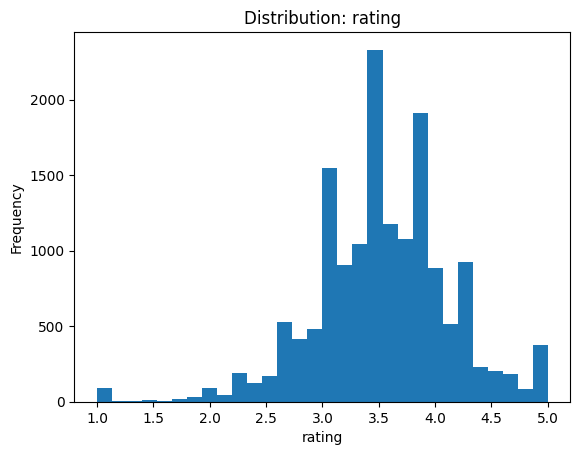

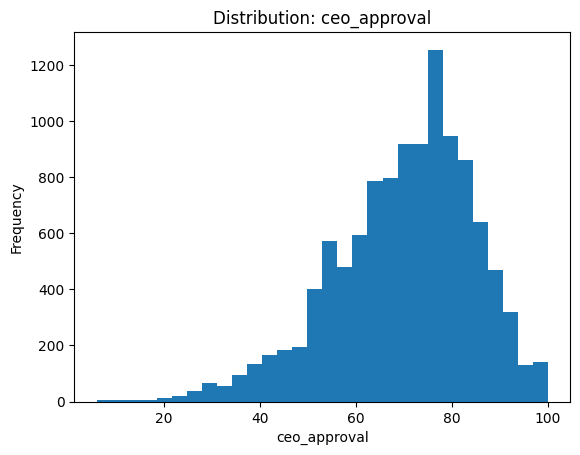

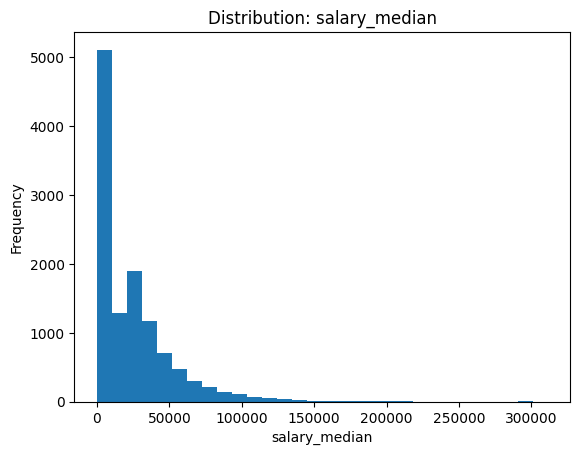

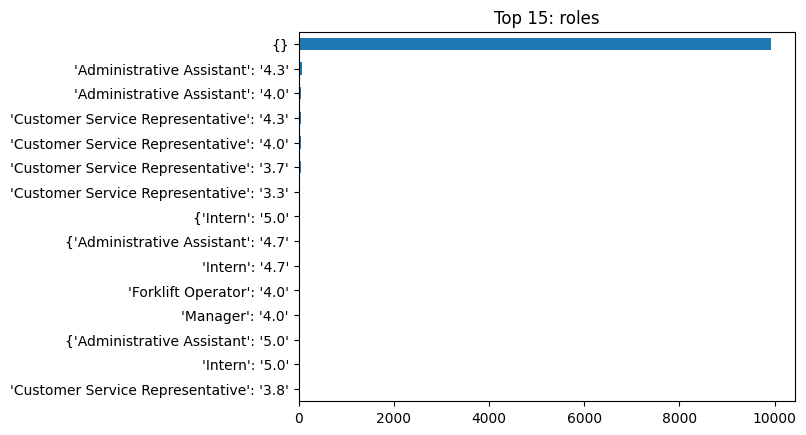

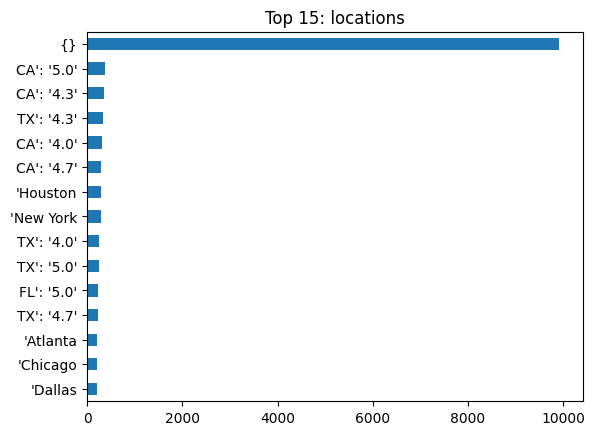

In [29]:
# Keep EDA tight (4–6 plots max). Add/remove columns based on your data.

def hist_if_exists(col):
    if col in df_clean.columns and df_clean[col].notna().any():
        plt.figure()
        df_clean[col].dropna().plot(kind="hist", bins=30, title=f"Distribution: {col}")
        plt.xlabel(col)
        plt.show()

for col in ["rating", "happiness", "ceo_approval", "salary_median"]:
    hist_if_exists(col)

# Top roles / locations (optional)
def top_k_listcol(col, k=15):
    if col not in df_clean.columns:
        return None
    items = []
    for lst in df_clean[col]:
        items.extend(lst if isinstance(lst, list) else [])
    s = pd.Series(items).value_counts().head(k)
    plt.figure()
    s.sort_values().plot(kind="barh", title=f"Top {k}: {col}")
    plt.show()
    return s

_ = top_k_listcol("roles", k=15)
_ = top_k_listcol("locations", k=15)


## 5) Build Retrieval Documents


In [30]:
# Define retrieval unit: start with 1 row -> 1 document.

NAME_COL = "name" if "name" in df_clean.columns else df_clean.columns[0]

def build_docs(df):
    docs = []
    for i, row in df.iterrows():
        meta = {"row_index": int(i), "company": str(row.get(NAME_COL, i))}
        # Keep a few structured signals for ranking/filters
        for c in ["rating","happiness","ceo_approval","salary_median","salary_min","salary_max","roles","locations"]:
            if c in df.columns:
                meta[c] = row.get(c)
        docs.append({"id": str(i), "text": str(row.get("doc_text","")), "meta": meta})
    return docs

docs = build_docs(df_clean)
print("Docs:", len(docs))
print("Example meta:", docs[0]["meta"])
print("Example text preview:", docs[0]["text"][:240])


Docs: 17050
Example meta: {'row_index': 0, 'company': 'Sitel', 'rating': nan, 'happiness': nan, 'ceo_approval': 70.0, 'salary_median': 41.5, 'salary_min': 11.0, 'salary_max': 72.0, 'roles': ["{'Tier 1 Agent': '5.0'", "'Director of Operations': '4.7'", "'Senior Vice President': '4.7'", "'Director of Finance': '4.7'", "'Sitel': '4.5'}"], 'locations': ["{'Paradise", "NV': '5.0'", "'Pioneer", "OH': '4.7'", "'Morocco", "IN': '4.6'", "'Kingston", "NY': '4.6'", "'Bartlett", "TN': '4.4'}"]}
Example text preview: Sitel Group’s 75,000 people across the globe connect many of the world’s best-known brands with their customers - 3.5 million times every day. As a global customer experience (CX) management leader, we apply our 30+ years of industry-leadin


## 6) Embeddings


In [31]:
from src.config import EMBED_MODEL, ARTIFACT_DIR
from src.embeddings import embed_texts
import numpy as np
import os

# Ensure artifact dir exists
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 1. Get list of text
# (Assuming 'docs' exists from Section 5. If not, run Section 5 first)
if 'docs' in locals():
    texts = [d["text"] for d in docs]
    print(f"Generating embeddings for {len(texts)} documents with {EMBED_MODEL}...")

    # 2. Embed
    emb = embed_texts(texts, EMBED_MODEL)

    # 3. Save
    save_path = os.path.join(ARTIFACT_DIR, "embeddings.npy")
    np.save(save_path, emb)
    print(f"Saved embeddings: {save_path} {emb.shape}")
else:
    print("Variable 'docs' not found. Please run Section 5 (Build Retrieval Documents) first.")

Generating embeddings for 17050 documents with BAAI/bge-large-en-v1.5...
Loading embedding model: BAAI/bge-large-en-v1.5 on cuda...
Embedding 17050 documents (batch_size=64)...


Batches:   0%|          | 0/267 [00:00<?, ?it/s]

Saved embeddings: artifacts/embeddings.npy (17050, 1024)


## 7) FAISS Index


In [33]:
# Install FAISS for GPU
!pip install -q faiss-gpu

# 1. Implement src/index.py
index_code = '''
import faiss
import numpy as np

def build_index(embeddings: np.ndarray) -> faiss.Index:
    """
    Builds a FAISS index using Inner Product (equivalent to Cosine Similarity if normalized).
    """
    d = embeddings.shape[1]
    # IndexFlatIP is exact search. Fast enough for <1M vectors on GPU.
    index = faiss.IndexFlatIP(d)
    index.add(embeddings)
    return index
'''
with open("src/index.py", "w") as f:
    f.write(index_code)
print("Created src/index.py")

# 2. Build & Save Index
import faiss
from src.index import build_index
from src.config import ARTIFACT_DIR
import os

if 'emb' in locals():
    print("Building FAISS index...")
    index = build_index(emb)

    index_path = os.path.join(ARTIFACT_DIR, "faiss.index")
    faiss.write_index(index, index_path)
    print(f"Saved index to {index_path}. Total vectors: {index.ntotal}")
else:
    print("Variable 'emb' not found. Please run Section 6 first.")

ERROR: Could not find a version that satisfies the requirement faiss-gpu (from versions: none)
ERROR: No matching distribution found for faiss-gpu
Created src/index.py
Building FAISS index...
Saved index to artifacts/faiss.index. Total vectors: 17050


## 8) Retrieval + Filters Demo


In [40]:
# 1. Implement src/retrieval.py
retrieval_code = '''
import numpy as np
from src.embeddings import embed_texts
from src.config import EMBED_MODEL

def search(query: str, index, docs: list, top_k: int = 10, filters: dict = None) -> list:
    """
    Semantic search with optional metadata filtering.
    """
    # 1. Embed query
    # Note: embed_texts returns (N, D), we need (1, D)
    q_emb = embed_texts([query], EMBED_MODEL, batch_size=1)[0].reshape(1, -1)

    # 2. Search FAISS (Fetch 5x top_k to allow for filtering attrition)
    fetch_k = top_k * 5
    scores, indices = index.search(q_emb, fetch_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < 0 or idx >= len(docs):
            continue

        doc = docs[idx]
        meta = doc.get("meta", {})

        # 3. Apply Filters
        if filters:
            match = True
            for key, val in filters.items():
                # Example: filter by "locations" (list check)
                if key == "location" and isinstance(meta.get("locations"), list):
                    if val not in meta["locations"]:
                        match = False; break
                # Example: filter by "min_rating"
                elif key == "min_rating":
                    if meta.get("rating", 0) < val:
                        match = False; break
            if not match:
                continue

        results.append({
            "id": str(idx),
            "score": float(score),
            "text": doc["text"],
            "meta": meta
        })

        if len(results) >= top_k:
            break

    return results
'''

with open("src/retrieval.py", "w") as f:
    f.write(retrieval_code)
print("Created src/retrieval.py")

# --- Demo Retrieval ---
from src.retrieval import search

# Ensure we have the index and docs loaded from previous cells
if 'index' in locals() and 'docs' in locals():
    query = "sharp eyes"
    print(f"\nQuery: {query}")

    # Test search
    results = search(query, index, docs, top_k=3)

    for i, r in enumerate(results):
        print(f"[{i+1}] Score: {r['score']:.4f} | Company: {r['meta']['company']}")
        print(f"    Text: {r['text'][:150]}...")
else:
    print("Skipping demo: 'index' or 'docs' not defined. Run Section 5 & 7 first.")

Created src/retrieval.py

Query: sharp eyes
Loading embedding model: BAAI/bge-large-en-v1.5 on cuda...
Embedding 1 documents (batch_size=1)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[1] Score: 0.6365 | Company: Wolfe Eye Clinic
    Text: Better Vision for Better Life! 16 reviews...
[2] Score: 0.6272 | Company: Midwest Eye Consultants
    Text: Midwest Eye Consultants wants our patients to love what they see, whether it is dew on a field of new corn, a back yard baseball game or a beautiful s...
[3] Score: 0.6094 | Company: The EyeDoctors
    Text: At The EyeDoctors, our highly trained staff of optometrists, opticians and technicians put patient care above all else. Each office is equipped with t...


## 9) Hybrid Ranking with User Priorities


In [25]:
# 1. Implement src/ranker.py
ranker_code = '''
def hybrid_score(results: list, priorities: dict) -> list:
    """
    Adjusts semantic search scores based on structured priorities.
    priorities: e.g. {"salary": 0.5, "rating": 0.3}
    """
    scored_results = []
    for r in results:
        # Start with semantic score (assumed normalized or cosine sim)
        final_score = r["score"]
        meta = r["meta"]

        # Boost by Rating
        if "rating" in priorities and meta.get("rating"):
            # Normalize rating 0-5 -> 0-1 approx
            norm_rating = meta["rating"] / 5.0
            final_score += priorities["rating"] * norm_rating

        # Boost by Salary
        if "salary" in priorities and meta.get("salary_median"):
            # Log scale salary to dampen massive outliers
            # Example assumption: 100k is baseline
            salary = meta["salary_median"]
            if salary > 0:
                import math
                norm_salary = math.log10(salary) / 6.0 # log10(100k)=5, log10(1m)=6
                final_score += priorities["salary"] * norm_salary

        r["hybrid_score"] = final_score
        scored_results.append(r)

    # Sort by new score
    return sorted(scored_results, key=lambda x: x["hybrid_score"], reverse=True)
'''

with open("src/ranker.py", "w") as f:
    f.write(ranker_code)
print("Created src/ranker.py")

# --- Demo Ranking ---
from src.ranker import hybrid_score

if 'results' in locals() and results:
    print("\n--- Re-ranking by Salary priority ---")
    priorities = {"salary": 0.5, "rating": 0.1}
    ranked = hybrid_score(results, priorities)

    for i, r in enumerate(ranked):
        sal = r['meta'].get('salary_median', 'N/A')
        print(f"[{i+1}] Hybrid: {r['hybrid_score']:.4f} (Sem: {r['score']:.4f}) | Salary: {sal} | {r['meta']['company']}")

Created src/ranker.py


## 10) RAG Answer Generation (Grounded)


In [26]:
# 1. Implement src/rag.py
rag_code = '''
from src.llm import generate_response

def build_context(results: list) -> str:
    context_parts = []
    for i, r in enumerate(results):
        meta = r["meta"]
        snippet = f"Document [{i+1}]\nCompany: {meta.get('company', 'Unknown')}"
        if "salary_median" in meta and meta["salary_median"]:
            snippet += f"\nMedian Salary: ${meta['salary_median']:,.0f}"
        if "rating" in meta:
            snippet += f"\nRating: {meta['rating']}/5.0"
        snippet += f"\nDescription: {r['text'][:500]}..." # Truncate to save tokens
        context_parts.append(snippet)
    return "\n\n".join(context_parts)

def ask_rag(query: str, results: list, model, tokenizer) -> str:
    context_str = build_context(results)

    prompt = f"""You are an expert AI Job Recruiter. Use the retrieved documents below to answer the candidate's query.

Query: "{query}"

Retrieved Documents:
{context_str}

Instructions:
1. Recommend the best options from the documents.
2. Explicitly cite the Document number [x] for every claim.
3. If the documents don't help, admit it.
4. Be concise and professional.

Answer:"""

    return generate_response(model, tokenizer, prompt)
'''

with open("src/rag.py", "w") as f:
    f.write(rag_code)
print("Created src/rag.py")

# --- Demo RAG ---
from src.rag import ask_rag

# Ensure model is loaded (from previous steps)
if 'model' in locals() and 'tokenizer' in locals() and 'ranked' in locals():
    print("\n--- Generative Answer ---")
    # Use the ranked results from previous section
    answer = ask_rag(query, ranked[:3], model, tokenizer)
    print(answer)
else:
    print("Model or results not ready. Please ensure Section 9 & Local LLM Setup are complete.")

Created src/rag.py


SyntaxError: unterminated f-string literal (detected at line 8) (rag.py, line 8)

## 11) Side-by-Side Comparison


In [ ]:
# TODO:
# - Select top N or user-selected companies
# - Create a structured comparison table
# - Ask LLM for a comparison summary (salary-first vs culture/WLB-first) with citations

raise NotImplementedError("Implement comparison utilities (suggest: src/compare.py), then run comparison here.")


## 12) Lightweight Evaluation


In [ ]:
# TODO:
# - Create a small set of test queries (10–30)
# - Log retrieval results and qualitative judgment
# - Optional: weak supervision Recall@K (if you can derive a 'ground truth' from metadata)

raise NotImplementedError("Implement eval (suggest: src/eval.py), then summarize metrics here.")


## 13) Gradio Demo UI


In [ ]:
# TODO:
# - Implement `build_app()` in src/ui.py returning a gradio Blocks app
# - UI should support:
#   - query box
#   - sliders for priorities
#   - optional role/location filters
#   - results table + RAG explanation

# Example:
# from src.ui import build_app
# demo = build_app()
# demo.launch(share=True)

raise NotImplementedError("Implement src/ui.py -> build_app(), then launch here.")


## 14) Save Artifacts + Local Run Notes


In [ ]:
# Optional artifact bundling:
# import shutil
# shutil.make_archive("artifacts_bundle", "zip", ARTIFACT_DIR)
# print("Created artifacts_bundle.zip")


## 15) Resume Bullets & Next Steps

- Built a RAG-based product discovery engine with FAISS semantic search over company reviews + metadata.
- Designed a hybrid ranking model combining embedding similarity with structured signals and user-weighted priorities.
- Deployed an interactive Gradio UI enabling natural-language search, filtering, and AI side-by-side comparisons with citations.


In [17]:
import os

# Define the content for src/llm.py (Optimized for L4 GPU & Caching)
llm_code = '''
import torch
import os
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Try to import cache dir from config, default to None if not found
try:
    from src.config import MODEL_CACHE_DIR
except ImportError:
    MODEL_CACHE_DIR = None

def load_qwen_model(model_name="Qwen/Qwen2.5-7B-Instruct"):
    """
    Loads the Qwen model from the local cache.
    - L4 GPU: Uses float16 (no quantization) for best performance.
    - T4 GPU: Uses 4-bit quantization.
    - CPU: Uses full precision (warning: slow).
    """
    print(f"Loading {model_name}...")
    if MODEL_CACHE_DIR:
        print(f"Using persistent cache: {MODEL_CACHE_DIR}")

    device_map = "cpu"
    quantization_config = None
    torch_dtype = torch.float32

    if torch.cuda.is_available():
        vram = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU Detected: {torch.cuda.get_device_name(0)} ({vram:.2f} GB VRAM)")

        if vram >= 20:
            print("Mode: Float16 (L4 Optimized)")
            device_map = "auto"
            torch_dtype = torch.float16
        else:
            print("Mode: 4-bit Quantization (T4 Optimized)")
            quantization_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True
            )
            device_map = "auto"
            torch_dtype = None
    else:
        print("Mode: CPU (Full Precision)")

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        cache_dir=MODEL_CACHE_DIR
    )

    # Load model
    load_kwargs = {
        "device_map": device_map,
        "trust_remote_code": True,
        "cache_dir": MODEL_CACHE_DIR
    }
    if quantization_config:
        load_kwargs["quantization_config"] = quantization_config
    if torch_dtype:
        load_kwargs["torch_dtype"] = torch_dtype

    model = AutoModelForCausalLM.from_pretrained(model_name, **load_kwargs)
    return model, tokenizer

def generate_response(model, tokenizer, prompt, max_new_tokens=512):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)
'''

# Write the file
os.makedirs("src", exist_ok=True)
with open("src/llm.py", "w") as f:
    f.write(llm_code)

print("\u2705 src/llm.py created successfully (Clean & Configured).")

✅ src/llm.py created successfully (Clean & Configured).


In [19]:
from src.config import LLM_MODEL
from src.llm import load_qwen_model, generate_response

# 1. Load the model (loads from local cache on Drive)
model, tokenizer = load_qwen_model(LLM_MODEL)

# 2. Generate a response
prompt = "tell a story about a cute piggy"
response = generate_response(model, tokenizer, prompt)

print("\nResponse:")
print(response)

Loading Qwen/Qwen2.5-7B-Instruct...
Using persistent cache: /content/drive/MyDrive/pyramyd_ml/model_cache
GPU detected. Loading in float16.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [20]:
prompt = "tell a story about a cute piggy"
response = generate_response(model, tokenizer, prompt)

print("\nResponse:")
print(response)

KeyboardInterrupt: 

In [ ]:
!pip install -q sentence-transformers

In [21]:
import os
import sys
import importlib

# 1. Update Config to use a better embedding model for L4
config_content = """
import os

# LLM (Using cached 7B model)
LLM_MODEL = "Qwen/Qwen2.5-7B-Instruct"

# Embeddings: BAAI/bge-large-en-v1.5 is SOTA and fits easily on L4
EMBED_MODEL = "BAAI/bge-large-en-v1.5"

ARTIFACT_DIR = "artifacts"

# Persistent cache directory
MODEL_CACHE_DIR = os.path.join(os.getcwd(), "model_cache")
os.makedirs(MODEL_CACHE_DIR, exist_ok=True)
"""

with open("src/config.py", "w") as f:
    f.write(config_content)
print("Updated src/config.py to use BAAI/bge-large-en-v1.5")

# 2. Implement src/embeddings.py
embeddings_code = '''
import torch
import numpy as np
from sentence_transformers import SentenceTransformer
try:
    from src.config import MODEL_CACHE_DIR
except ImportError:
    MODEL_CACHE_DIR = None

def embed_texts(texts: list[str], model_name: str, batch_size: int = 64) -> np.ndarray:
    """
    Generates embeddings for a list of texts using SentenceTransformers.
    Auto-detects GPU and normalizes embeddings for cosine similarity.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading embedding model: {model_name} on {device}...")

    # Load model (using cache if available)
    model = SentenceTransformer(model_name, device=device, cache_folder=MODEL_CACHE_DIR)

    print(f"Embedding {len(texts)} documents (batch_size={batch_size})...")

    # Encode
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True, # Vital for dot-product/cosine retrieval
        convert_to_numpy=True
    )

    return embeddings
'''

with open("src/embeddings.py", "w") as f:
    f.write(embeddings_code)
print("Created src/embeddings.py")

# 3. Test the Embedding implementation
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

import src.config
importlib.reload(src.config)
from src.config import EMBED_MODEL
from src.embeddings import embed_texts

# Dummy test data
test_docs = [
    "The L4 GPU is great for AI inference.",
    "Qwen is a powerful open-source LLM.",
    "RAG combines retrieval with generation."
]

print(f"\nTesting embedding generation with {EMBED_MODEL}...")
emb = embed_texts(test_docs, EMBED_MODEL)

print(f"\nSuccess! Output shape: {emb.shape}")
print(f"Sample (first 3 dims): {emb[0][:3]}")

Updated src/config.py to use BAAI/bge-large-en-v1.5
Created src/embeddings.py

Testing embedding generation with BAAI/bge-large-en-v1.5...
Loading embedding model: BAAI/bge-large-en-v1.5 on cuda...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Embedding 3 documents (batch_size=64)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Success! Output shape: (3, 1024)
Sample (first 3 dims): [ 0.02986128  0.02219985 -0.01565308]
